# Exp-05 Skin Color Detection

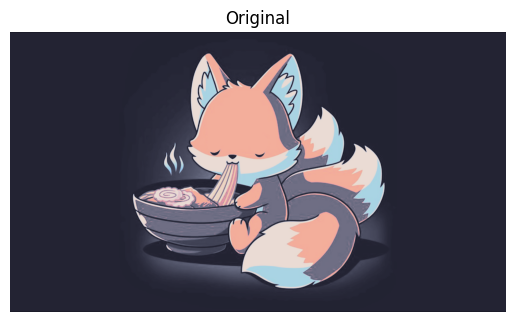

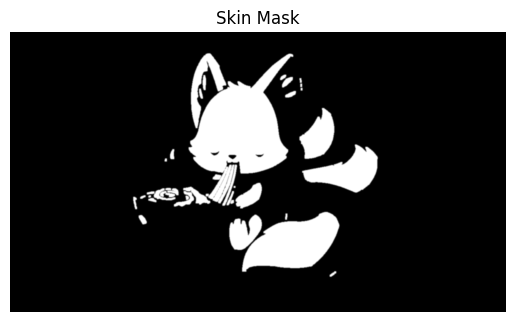

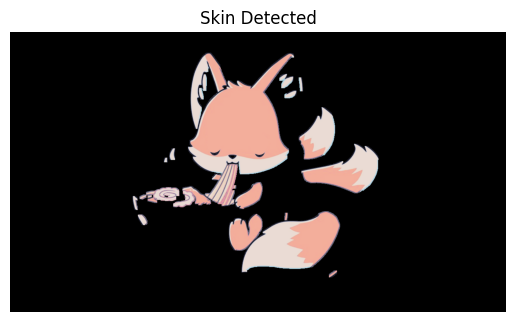

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('fox.png')

if img is None:
    print("Error loading image")
    exit()

# Convert BGR to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# ---------------------------
# Define skin color range
# ---------------------------
# Lower and upper HSV values for skin
lower_skin = np.array([0, 20, 70], dtype=np.uint8)
upper_skin = np.array([20, 255, 255], dtype=np.uint8)

# Create mask
mask = cv2.inRange(hsv, lower_skin, upper_skin)

# ---------------------------
# Remove noise (optional but useful)
# ---------------------------
kernel = np.ones((3, 3), np.uint8)

mask = cv2.erode(mask, kernel, iterations=1)   # remove small noise
mask = cv2.dilate(mask, kernel, iterations=2)  # restore shape
mask = cv2.GaussianBlur(mask, (5, 5), 0)       # smooth edges

# ---------------------------
# Extract skin region
# ---------------------------
skin = cv2.bitwise_and(img, img, mask=mask)

# Convert BGR → RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
skin_rgb = cv2.cvtColor(skin, cv2.COLOR_BGR2RGB)

# Show results
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')
plt.show()

plt.imshow(mask, cmap='gray')
plt.title("Skin Mask")
plt.axis('off')
plt.show()

plt.imshow(skin_rgb)
plt.title("Skin Detected")
plt.axis('off')
plt.show()